# Comparacion robusta: Etapa 3 vs Etapa 4 con multiples semillas

**Por que este notebook existe:** al comparar Etapa 3 contra Etapa 4 con una sola corrida
de cada una, el IoU/PAI salio distinto cada vez que se re-corrio el MISMO codigo (0.0000,
0.2024, 0.2882, 0.3334...). La causa: no habia semilla fija (pesos iniciales y dropout
aleatorios en cada corrida) combinado con un test set de solo 2 secuencias, donde el
IoU/PAI son muy sensibles a que celdas exactas caen en el "10% mas denso". El MAE/RMSE
se promedian sobre miles de pixeles y por eso salen estables; el IoU/PAI no.

**Que hace este notebook:** entrena la configuracion de Etapa 3 y la de Etapa 4, cada una
`N_REPETICIONES` veces con semillas distintas, y compara el **promedio +/- desviacion
estandar** de cada metrica -- no un solo numero suelto. Solo asi se puede saber si la
Etapa 4 realmente mejora sobre la Etapa 3, o si la diferencia que vimos antes era puro
ruido de inicializacion.

**Costo:** esto entrena el modelo `2 configs x N_REPETICIONES` veces (por defecto 5+5=10
entrenamientos completos de 50 epocas). Va a tardar bastante mas que una corrida sola.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
 #Para comprobar el tipo de GPU asignada, utilizamos el siguiente comando.
!nvidia-smi

Fri Jul 24 18:46:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ============================================================================
# 1. IMPORTS
# ============================================================================
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, Conv3D, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.ndimage import zoom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import glob
import os
import re
import random
import warnings
warnings.filterwarnings("ignore")

In [4]:
# ======================================================
# OPTIMIZACION GPU PARA GOOGLE COLAB
# ======================================================
from tensorflow.keras import backend as K
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU configurada con memory growth habilitado")
    except RuntimeError as e:
        print(e)

GPU configurada con memory growth habilitado


In [5]:
# ============================================================================
# 2. PARAMETROS
# ============================================================================
ruta_rasters = '/content/drive/MyDrive/Raster_nuevo/kde_200_5m_*.tif'
ruta_salida = '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output_comparacion_semillas/'
os.makedirs(ruta_salida, exist_ok=True)

# MEJORA: siguen igual de sin-justificar que en etapas anteriores (ver checklist previo).
target_shape = (90, 124)
row, col = target_shape
n_frames = 12
test_size = 0.2
val_size = 0.1
batch_size = 11
epochs = 50
num_capas = 4
threshold_percentage = 10

# ======================================================
# Cuantas repeticiones por configuracion, y con que semillas
# ======================================================
N_REPETICIONES = 3
SEEDS = [1, 2, 3]

# ======================================================
# Las 2 configuraciones a comparar (Etapa 3 vs Etapa 4)
# ======================================================
CONFIGURACIONES = {
    "Etapa 3 (mse plano, dropout 0.3, sin log)": {
        "usar_log": False,
        "dropout_rate": 0.3,
        "l2_reg": 1e-4,
        "alpha_perdida": 0.0,   # alpha=0 -> la perdida ponderada se reduce a MSE normal
    },
    "Etapa 4 (perdida ponderada, dropout 0.1, log)": {
        "usar_log": True,
        "dropout_rate": 0.1,
        "l2_reg": 1e-5,
        "alpha_perdida": 5.0,
    },
}

print("Configurado OK")

Configurado OK


In [6]:
# ============================================================================
# 3. FUNCIONES AUXILIARES (identicas a Etapas 3 y 4)
# ============================================================================

def extraer_year_month(nombre_archivo):
    '''Extrae (year, month) para ordenar cronologicamente (fix de la Etapa 3).'''
    m = re.search(r'_(\d{4})_(\d{1,2})\.tif$', nombre_archivo)
    if not m:
        raise ValueError(f"No se pudo extraer year/month de: {nombre_archivo}")
    return (int(m.group(1)), int(m.group(2)))


def cargar_y_redimensionar_rasters(ruta_rasters, target_shape, usar_log):
    '''Carga y redimensiona los rasters, con orden cronologico correcto y
    log-transform opcional (Etapa 4, Cambio 3).'''
    rasters = glob.glob(ruta_rasters)
    if len(rasters) == 0:
        raise ValueError(f"No se encontraron archivos en la ruta: {ruta_rasters}")
    rasters = sorted(rasters, key=extraer_year_month)

    sequences = []
    for raster in rasters:
        try:
            with rasterio.open(raster) as src:
                image = src.read(1)
                zoom_factors = (target_shape[0] / image.shape[0], target_shape[1] / image.shape[1])
                sequences.append(zoom(image, zoom_factors, order=1))
        except Exception as e:
            print(f"Error procesando {raster}: {e}")
            continue

    sequences = np.array(sequences, dtype=np.float32)
    if usar_log:
        sequences = np.log1p(sequences)
    sequences = sequences / sequences.max()
    return sequences


def dividir_datos_temporales(sequences, test_size=0.2):
    n_total = len(sequences)
    n_test = int(n_total * test_size)
    return sequences[:-n_test], sequences[-n_test:]


def generar_secuencias(sequences, n_frames=12):
    n_samples = sequences.shape[0] - n_frames
    if n_samples <= 0:
        raise ValueError(f"No hay suficientes frames. Se necesitan al menos {n_frames + 1}.")
    X = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    y = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    for i in range(n_samples):
        X[i, :, :, :, 0] = sequences[i:i + n_frames]
        y[i, :, :, :, 0] = sequences[i + 1:i + n_frames + 1]
    return X, y


def crear_perdida_ponderada(alpha=5.0):
    '''alpha=0 -> se reduce a un MSE normal (Etapa 3 usa alpha=0 aqui para poder
    reusar el mismo codigo de entrenamiento en ambas configuraciones).'''
    def perdida_ponderada(y_true, y_pred):
        peso = 1.0 + alpha * y_true
        return tf.reduce_mean(peso * tf.square(y_true - y_pred))
    return perdida_ponderada


def crear_modelo_convlstm(input_shape, num_capas, dropout_rate, l2_reg):
    model = Sequential()
    for i in range(num_capas):
        model.add(ConvLSTM2D(
            filters=37, kernel_size=(3, 3),
            input_shape=input_shape if i == 0 else None,
            padding='same', return_sequences=True,
            dropout=dropout_rate, recurrent_dropout=dropout_rate,
            kernel_regularizer=l2(l2_reg), recurrent_regularizer=l2(l2_reg)
        ))
        if i < num_capas - 1:
            model.add(BatchNormalization())
    model.add(Conv3D(filters=1, kernel_size=(3, 3, 3), activation='sigmoid', padding='same'))
    return model


def discretize_heatmap(heatmap, threshold_percentage):
    threshold_value = np.percentile(heatmap, 100 - threshold_percentage)
    return (heatmap >= threshold_value).astype(int)


def calculate_iou(predicted_hotspots, true_hotspots):
    intersection = np.sum((predicted_hotspots == 1) & (true_hotspots == 1))
    union = np.sum((predicted_hotspots == 1) | (true_hotspots == 1))
    return 1.0 if union == 0 else intersection / union


def calculate_pai(predicted_hotspots, true_crime_locations):
    total_area = predicted_hotspots.size
    hotspot_area = np.sum(predicted_hotspots)
    if hotspot_area == 0:
        return 0.0
    total_crimes = len(true_crime_locations)
    if total_crimes == 0:
        return 0.0
    crimes_in_hotspots = sum(
        1 for r, c in true_crime_locations
        if 0 <= r < predicted_hotspots.shape[0] and 0 <= c < predicted_hotspots.shape[1]
        and predicted_hotspots[r, c] == 1
    )
    percentage_crimes = crimes_in_hotspots / total_crimes
    percentage_area = hotspot_area / total_area
    return percentage_crimes / percentage_area


print("Funciones definidas OK")

Funciones definidas OK


In [7]:
# ============================================================================
# 4. CARGAR AMBOS CONJUNTOS DE SECUENCIAS UNA SOLA VEZ
# ============================================================================
# El log-transform es la unica parte que depende de la config y no de la semilla, asi
# que se calcula una vez por tipo de secuencia (lineal / log) y se reutiliza en las
# repeticiones -- evita releer 72 rasters de Drive 10 veces innecesariamente.
print("Cargando secuencias SIN log-transform (para Etapa 3)...")
sequences_lineal = cargar_y_redimensionar_rasters(ruta_rasters, target_shape, usar_log=False)

print("Cargando secuencias CON log-transform (para Etapa 4)...")
sequences_log = cargar_y_redimensionar_rasters(ruta_rasters, target_shape, usar_log=True)

secuencias_por_config = {
    "Etapa 3 (mse plano, dropout 0.3, sin log)": sequences_lineal,
    "Etapa 4 (perdida ponderada, dropout 0.1, log)": sequences_log,
}
print("Listo.")

Cargando secuencias SIN log-transform (para Etapa 3)...
Cargando secuencias CON log-transform (para Etapa 4)...
Listo.


In [8]:
# ============================================================================
# 5. FUNCION QUE ENTRENA Y EVALUA UNA SOLA CORRIDA (una config, una semilla)
# ============================================================================

def entrenar_y_evaluar_una_vez(nombre_config, sequences, params, seed):
    '''Corre el pipeline completo (split, secuencias, modelo, entrenamiento,
    evaluacion global + espacial de un frame + autorregresiva de 12 meses) UNA vez,
    con la semilla dada, y devuelve un dict con todas las metricas.'''

    # --- Fijar semillas para esta corrida ---
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    K.clear_session()

    # --- Datos (el split y las secuencias dependen del orden, no de la semilla,
    #     pero se regeneran aqui por claridad y para que cada corrida sea autonoma) ---
    train_sequences, test_sequences = dividir_datos_temporales(sequences, test_size)
    X_train, y_train = generar_secuencias(train_sequences, n_frames)
    X_test, y_test = generar_secuencias(test_sequences, n_frames)

    # --- Modelo ---
    input_shape = (n_frames, row, col, 1)
    model = crear_modelo_convlstm(input_shape, num_capas, params["dropout_rate"], params["l2_reg"])
    perdida = crear_perdida_ponderada(alpha=params["alpha_perdida"])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss=perdida, metrics=['mae'])

    earlystop_cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

    model.fit(
        X_train, y_train, epochs=epochs, batch_size=batch_size,
        validation_split=val_size, callbacks=[earlystop_cb, reduce_lr_cb], verbose=0
    )

    # --- Evaluacion global (MAE/RMSE sin ponderar, comparable entre configs) ---
    y_pred = model.predict(X_test, verbose=0)
    mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))

    # --- IoU/PAI de un frame ---
    true_map = y_test[-1, -1, :, :, 0]
    pred_map = y_pred[-1, -1, :, :, 0]
    true_hs = discretize_heatmap(true_map, threshold_percentage)
    pred_hs = discretize_heatmap(pred_map, threshold_percentage)
    iou_frame = calculate_iou(pred_hs, true_hs)
    pai_frame = calculate_pai(pred_hs, np.argwhere(true_hs == 1))

    # --- Prediccion autorregresiva de 12 meses + IoU/PAI temporal ---
    track = X_test[-1].copy()
    predicted_sequence = []
    for _ in range(12):
        new_pos = model.predict(track[np.newaxis, :, :, :, :], verbose=0)
        new_frame = new_pos[:, -1, :, :, :]
        predicted_sequence.append(new_frame[0])
        track = np.concatenate((track[1:], new_frame[0:1]), axis=0)
    predicted_sequence = np.array(predicted_sequence)

    ious, pais = [], []
    for t in range(min(12, y_test.shape[0])):
        true_hs_t = discretize_heatmap(y_test[t, -1, :, :, 0], threshold_percentage)
        pred_hs_t = discretize_heatmap(predicted_sequence[t, :, :, 0], threshold_percentage)
        ious.append(calculate_iou(pred_hs_t, true_hs_t))
        pais.append(calculate_pai(pred_hs_t, np.argwhere(true_hs_t == 1)))

    resultado = {
        "config": nombre_config,
        "seed": seed,
        "MAE": mae,
        "RMSE": rmse,
        "IoU_frame": iou_frame,
        "PAI_frame": pai_frame,
        "IoU_temporal": np.mean(ious),
        "PAI_temporal": np.mean(pais),
    }
    print(f"  [{nombre_config[:20]:<20} | seed={seed}] MAE={mae:.4f} RMSE={rmse:.4f} "
          f"IoU_temp={np.mean(ious):.4f} PAI_temp={np.mean(pais):.4f}")
    return resultado


print("Funcion de entrenamiento definida OK")

Funcion de entrenamiento definida OK


In [9]:
# ============================================================================
# 6. LOOP PRINCIPAL: 2 configs x N_REPETICIONES semillas
# ============================================================================
resultados = []

for nombre_config, params in CONFIGURACIONES.items():
    sequences = secuencias_por_config[nombre_config]
    print(f"\n=== {nombre_config} ===")
    for seed in SEEDS[:N_REPETICIONES]:
        res = entrenar_y_evaluar_una_vez(nombre_config, sequences, params, seed)
        resultados.append(res)

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(os.path.join(ruta_salida, 'resultados_por_semilla.csv'), index=False)
df_resultados


=== Etapa 3 (mse plano, dropout 0.3, sin log) ===
  [Etapa 3 (mse plano,  | seed=1] MAE=0.0761 RMSE=0.0972 IoU_temp=0.2938 PAI_temp=4.5341
  [Etapa 3 (mse plano,  | seed=2] MAE=0.0701 RMSE=0.0890 IoU_temp=0.2985 PAI_temp=4.5923
  [Etapa 3 (mse plano,  | seed=3] MAE=0.0859 RMSE=0.1111 IoU_temp=0.2050 PAI_temp=3.3961

=== Etapa 4 (perdida ponderada, dropout 0.1, log) ===
  [Etapa 4 (perdida pon | seed=1] MAE=0.0858 RMSE=0.1087 IoU_temp=0.2083 PAI_temp=3.4453
  [Etapa 4 (perdida pon | seed=2] MAE=0.0781 RMSE=0.0978 IoU_temp=0.1667 PAI_temp=2.8539
  [Etapa 4 (perdida pon | seed=3] MAE=0.0985 RMSE=0.1257 IoU_temp=0.1443 PAI_temp=2.5179


,config,seed,MAE,RMSE,IoU_frame,PAI_frame,IoU_temporal,PAI_temporal
0,"Etapa 3 (mse plano, dropout 0.3, sin log)",1,0.076140,0.097212,0.239311,3.862007,0.293824,4.534050
1,"Etapa 3 (mse plano, dropout 0.3, sin log)",2,0.070101,0.089050,0.332537,4.991039,0.298516,4.592294
2,"Etapa 3 (mse plano, dropout 0.3, sin log)",3,0.085904,0.111084,0.213043,3.512545,0.204963,3.396057
3,"Etapa 4 (perdida ponderada, dropout 0.1, log)",1,0.085754,0.108680,0.196141,3.279570,0.208254,3.445341
4,"Etapa 4 (perdida ponderada, dropout 0.1, log)",2,0.078054,0.097784,0.163106,2.804659,0.166690,2.853943
5,"Etapa 4 (perdida ponderada, dropout 0.1, log)",3,0.098529,0.125735,0.161290,2.777778,0.144282,2.517921


In [10]:
# ============================================================================
# 7. AGREGACION: PROMEDIO +/- DESVIACION ESTANDAR POR CONFIGURACION
# ============================================================================
resumen = df_resultados.groupby("config")[["MAE", "RMSE", "IoU_frame", "PAI_frame",
                                            "IoU_temporal", "PAI_temporal"]].agg(['mean', 'std'])
print("Resumen (promedio +/- desviacion estandar entre las", N_REPETICIONES, "semillas):\n")
print(resumen.round(4))

resumen.to_csv(os.path.join(ruta_salida, 'resumen_agregado.csv'))

Resumen (promedio +/- desviacion estandar entre las 3 semillas):

                                                  MAE            RMSE          \
                                                 mean     std    mean     std   
config                                                                          
Etapa 3 (mse plano, dropout 0.3, sin log)      0.0774  0.0080  0.0991  0.0111   
Etapa 4 (perdida ponderada, dropout 0.1, log)  0.0874  0.0103  0.1107  0.0141   

                                              IoU_frame         PAI_frame  \
                                                   mean     std      mean   
config                                                                      
Etapa 3 (mse plano, dropout 0.3, sin log)        0.2616  0.0628    4.1219   
Etapa 4 (perdida ponderada, dropout 0.1, log)    0.1735  0.0196    2.9540   

                                                      IoU_temporal          \
                                                  std         me

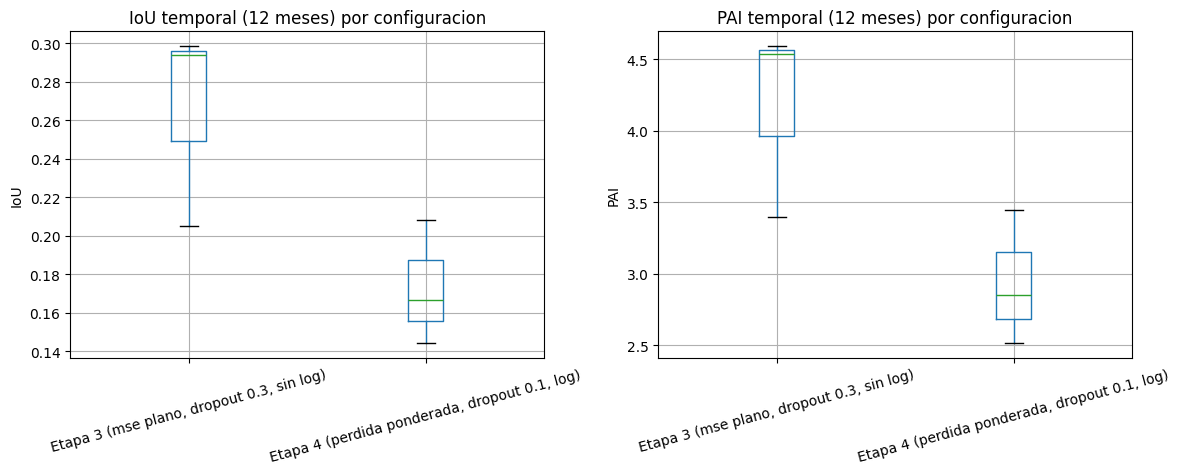

In [11]:
# ============================================================================
# 8. VISUALIZACION: boxplots de IoU y PAI por configuracion
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_resultados.boxplot(column="IoU_temporal", by="config", ax=axes[0])
axes[0].set_title("IoU temporal (12 meses) por configuracion")
axes[0].set_xlabel(""); axes[0].set_ylabel("IoU")
axes[0].tick_params(axis='x', rotation=15)

df_resultados.boxplot(column="PAI_temporal", by="config", ax=axes[1])
axes[1].set_title("PAI temporal (12 meses) por configuracion")
axes[1].set_xlabel(""); axes[1].set_ylabel("PAI")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("")
plt.tight_layout()
plt.savefig(os.path.join(ruta_salida, 'boxplot_comparacion.png'), dpi=200, bbox_inches='tight')
plt.show()

## Como leer el resultado

- Si las **cajas de los boxplots no se solapan** (o se solapan muy poco) entre Etapa 3 y
  Etapa 4, hay evidencia razonable de que una configuracion es genuinamente mejor que la
  otra -- no es solo el azar de la semilla.
- Si las cajas **se solapan bastante**, con `N_REPETICIONES=5` todavia no hay evidencia
  suficiente para afirmar que una gana; se necesitarian mas repeticiones, o atacar
  primero el problema de fondo (el tamano del test set de 2 secuencias, que es lo que
  esta generando tanta varianza en primer lugar).
- La tabla de `resumen` (mean +/- std) es la version numerica de lo mismo: si
  `mean(Etapa4) - mean(Etapa3)` es mas chico que 1-2 desviaciones estandar combinadas,
  la diferencia no es concluyente todavia.

**Siguiente paso mas probable segun lo que salga aqui:** si incluso con 5 repeticiones
la varianza sigue siendo enorme, el problema de fondo no es la perdida ni la
regularizacion (Etapa 4) -- es que 2 secuencias de test es estadisticamente muy poco
para evaluar nada con confianza, y valdria la pena conseguir mas datos de test (mas
años de historia, o repensar el split) antes de seguir ajustando hiperparametros.